In [1]:
import sys, os
from pathlib import Path
from pprint import pprint
from collections import defaultdict

import numpy as np
import torch
import networkx as nx
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
from tqdm import tqdm
import spectral

from sklearn.metrics import precision_recall_fscore_support#confusion_matrix

import yaml

BASE_DIR = Path.cwd().resolve().parent.parent
sys.path.append(str(BASE_DIR))
SCRIPT_DIR = Path.cwd().resolve()
CFG_DIR = SCRIPT_DIR / 'configs'
RESULTS_DIR = SCRIPT_DIR / 'results'


from src.models.lr_ssd.snn__logn_gtv import SNN__LOGN_GTV
from src.models.tucker_decomp.hosvd import hosvd
from src.metrics.estimate_rank import estimate_tucker_rank
from src.multilinear_ops.matricize import matricize

from src.multilinear_ops.mode_product import mode_product
from src.multilinear_ops.tensorize import tensorize
from src.gsp.gsp_vis import draw_graph_signal
# Class used to import Server Machine Dataset and NYC Taxi Dataset with 
# Spatial and Temporal Graphs
from data.server_machine_dataset import SMDMachineChannel
from data.nyc_taxi_dataset import NYCTaxiDataset
from data.hsi_abu_dataset import ABUHyperSpectral


plt.style.use('seaborn-v0_8-paper')
# Set the default font family to serif
plt.rcParams['font.family'] = 'serif' 
# Specify a list of font names to try for the serif family
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Palatino']

To compare the models behaviors, we chose 4 models for 3 images to visualize.
Image: Airport-2
Models: HoRPCA, $\mathrm{\ell_1 + GTV(S)}$, $\mathrm{LOGN(S-E) + GTV(S)+GTV(T)}$, $\mathrm{LOGN(S-E)}$
Image: Urban-4
Models: HoRPCA, RTD-OITNN-O, $\mathrm{LOGN(S-E) + GTV(S)+GTV(T)}$, $\mathrm{LOGN(S-E)}$

Image: Urban-1

In [2]:

model_keys = ['HoRPCA',
              'SNN_LOGNSE',
            'SNN_LOGNTE',
            'SNN_LOGNSE',
            'SNN_LOGNSTE',
            # 'SNN_LOGN',
            # 'SNN_LOGNST',
            'SNN_L1_GTV_T',
            'SNN_L1_GTVS_sn',
            # 'SNN_LOGN_SN_GTV_T',
            # "SNN_LOGN_SN_GTV_S",
            # 'SNN_LOGNST_GTVST',
            ]

with open(CFG_DIR / 'model_configs.yaml') as f:
    model_configs = yaml.safe_load(f)
model_names = [ model_configs[key]['name'] for key in model_keys]

def run_model_on_img(model_key, category, image_id, use_post_ocsvm=False, k=3):
    data = ABUHyperSpectral(category,image_id)
    Y = data.Y
    variance_estimate = data.scaled_var_ests[category][image_id-1]
    sigma = variance_estimate**0.5
    model_config = model_configs[model_key]
    model_select = { # Model selection based on the model_config
                'graph': model_config['graph'],
                'lr_modes': [1,2,3],
                'graph_modes': model_config['graph_modes'],
                'grouping': model_config['grouping'],
                'weighing': 'size_normalized',
                'r_hop': model_config['r_hop'],
                'soft_constrained': False,
                'device': model_config.get('device', 'cuda' if torch.cuda.is_available() else 'cpu'),
                'dtype': model_config.get('dtype', torch.float64),
                'verbose': 0,
                'gtvr_config': model_config['gtvr_config'],
                'report_freq': 2000,
                'sp_solve': False,
                'precompute_inv': True,
                }
    model_run = {
                'max_iter': 500,#5000,
                'rho': 0.3,#model_config.get('rho', 50.3),
                'err_tol': model_config.get('err_tol', 1e-4),
                'rho_update': model_config.get('rho_update', 'domain_parametrization'),
                'rho_update_thr': model_config.get('rho_update_thr', 100)
        }
    Gtu = nx.grid_graph((Y.shape[2], ), periodic=False)
    Gt = Gtu
    Gt = nx.DiGraph([(u, v) for u, v in Gtu.edges() if u <= v and u <= v])
    
    Gsu = nx.grid_graph((Y.shape[0],Y.shape[1]), periodic=False)
    Gs = Gsu
    Gs = nx.DiGraph([(u, v) for u, v in Gsu.edges() if u[0] <= v[0] and u[1] <= v[1]])
    if model_select['graph'] == 'temporal':
        G = Gt
        model_select['graph_modes'] = [3]
    elif model_select['graph'] == 'spatial':
        G = Gs
        model_select['graph_modes'] = [1,2]
    elif model_select['graph'] == 'spatio-temporal':
        G = nx.cartesian_product(Gs, Gt)
        model_select['graph_modes'] = [1,2,3]
    else:
        raise ValueError(f"Unknown graph type: {model_select['graph']}")


    Y = data.Y
    ranges = (np.quantile( Y.ravel(), 0.9), np.quantile( Y.ravel(), 0.1))
    scale = float(ranges[0]-ranges[1])
    Y = Y / scale
    for g, gtv_regularization in enumerate(model_config['gtvr_config']):
        if gtv_regularization['graph'] == 'temporal':
            gtv_regularization['mode'] = [3]
        elif gtv_regularization['graph'] == 'spatial':
            gtv_regularization['mode'] = [1,2]
        elif gtv_regularization['graph'] == 'spatio-temporal':
            gtv_regularization['mode'] = [1,2,3]
        gtv_regularization['normalization'] = 'none'
            # gtv_regularization['mode']['p']
        modes = gtv_regularization['mode']
        dims = [Y.shape[m-1] for m in modes]
        num_gtv_vertices = np.prod(dims)
                # sqrt(Estimated variance) * sqrt(2*log(number_of_variates_to_penalize))
                # This is based on the paper "Atomic Decomposition by Basis Pursuit"
    model = SNN__LOGN_GTV(Y, G, **model_select)
    group_sizes = model.expander.sum(axis=1).to_dense()
    group_size_arithmetic_mean = group_sizes.mean().item()
    num_groups = model.expander.shape[0]
    D= Y.size
    lda = 1/(group_size_arithmetic_mean*(np.max(Y.shape)**0.5))
    # lda = 1/((np.max(Y.shape))**0.5)
                # sqrt(Estimated variance) * sqrt(2*log(number_of_variates_to_penalize))
                # This is based on the paper "Atomic Decomposition by Basis Pursuit"
    lda_gtvs = [
            
            np.sqrt(2*np.log(num_gtv_vertices)/D)
                for g in range(len(model_config['gtvr_config']))]
    
    psis = [1,1,1]
    X, S = model(psis,
                lda,
                lda_gtvs,
                 lda_f=1.0,
                **model_run)
    scores = ((model.S*scale)**2).sum(dim=2).sqrt().cpu().numpy()
    # scores = np.sum(((model.S.cpu().numpy()/scales)**2), axis=2)**0.5
    # scores = (scores )
    # std = model.S.std()
    t_labels = scores > sigma*k#lda*k

    print(f"pri res: {float(model.r[-1])} d res: {float(model.s[-1])}")
    
    scoring_score = data.anomaly_scoring_score(scores)
    detection_score = data.anomaly_detection_score(t_labels)
    scoring_score.pop('st_scores', None)
    scoring_score.pop('t_scores', None)
    results = {**scoring_score, **detection_score}
    if use_post_ocsvm:
        scores = np.zeros_like(model.S.cpu().numpy())
        Snpy = S.cpu().numpy()
        t_labels = np.zeros_like(Snpy, dtype=bool)
        for l in range(Y.shape[0]):
            for d in range(Y.shape[1]):
                for h in range(Y.shape[3]):
                    s = Snpy[l,d, :, h].reshape(-1, 1)
                    clf = OneClassSVM(gamma='scale',
                                    kernel='rbf',
                                    nu=0.01,
                                    verbose=0).fit(s)
                    ld_scores = clf.score_samples(s)
                    ld_labels = clf.predict(s).ravel()
                    scores[l,d,:,h] = ld_scores.reshape(Snpy.shape[2])
                    t_labels[l,d,:,h] = ld_labels.reshape(Snpy.shape[2])
        scores = scores
        
        t_labels = (t_labels == 1)
        ocsvm_scoring_score = data.anomaly_scoring_score(scores) 
        ocsvm_detection_score = data.anomaly_detection_score(t_labels)
        ocsvm_scoring_score.pop('st_scores', None)
        ocsvm_scoring_score.pop('t_scores', None)
        ocsvm_results = {**ocsvm_scoring_score, **ocsvm_detection_score}
        return results, ocsvm_results
    return results, data, model, scale

## Urban-1

In [ ]:
DECOMP_DIR = RESULTS_DIR / 'decomposed_images'

# category='urban'
# image_id=1
# model_keys = ['HoRPCA', 'SNN_LOGNSE', 'SNN_LOGN', 'SNN_L1_GTVS_sn']
category='airport'
image_id=2
model_keys = ['HoRPCA', 'SNN_L1_GTVS_sn', 'SNN_LOGNSE', 'SNN_LOGNSE_GTVS_GTVT']
for m_key in model_keys:
    print(m_key)
    results, data, model, scale = run_model_on_img(m_key, category, image_id)
    model.V.shape
    Vsum = model.V.sum(dim=0, keepdim=True).coalesce().to_dense()
    scores = ((Vsum*scale)**2).sum(dim=2).sqrt().cpu().numpy()
    S = tensorize(Vsum, model.Y.shape, model.graph_modes)
    S.shape
    pprint(results)
    print("Zero Ratio:", ((S==0).sum()/ S.numel()).item())
    vsum_score = data.anomaly_scoring_score(scores)
    vsum_score.pop('st_scores', None)
    vsum_score.pop('t_scores', None)
    print("Scores with V:")
    pprint(vsum_score)
    file_path = DECOMP_DIR / f"{category}_{image_id}_{m_key}"
    saved_arrays = {
        "X": model.X.cpu().numpy(),
        "S": model.S.cpu().numpy(),
        "Vsum": S.cpu().numpy(),
        "scale": scale,
    }
    np.savez(file_path, **saved_arrays)

In [2]:
%matplotlib inline
# import hyperspy.api as hs
# from mayavi import mlab
# mlab.options.backend = 'envisage'

from sklearn.metrics import (precision_recall_curve,
                             roc_curve,
                             PrecisionRecallDisplay,
                             auc,
                             RocCurveDisplay
                             )
# fpr, tpr, thresholds = metrics.roc_curve(y_true, y_score)
# roc_auc = metrics.auc(fpr, tpr)
# display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
#                                   name='example estimator')

In [154]:
from matplotlib.legend_handler import HandlerErrorbar
suptitle_cfg = {
    'fontsize': 22,
    'fontweight': 'bold',
    # 'x': 0.1,
    'y': 1.02,
}
legend_cfg = { 'loc': 'lower right',
               'ncol':1,
               'framealpha':1.0,
               'scatterpoints':2,
               'title':'Models',
               'title_fontsize':14,
               'alignment': 'center',
               'fontsize':12,
               'edgecolor':'black',
               'facecolor':'white',
               'numpoints':2,
               'handlelength':2.5,
               'columnspacing':2.0,
               'fancybox':False,
               'frameon':True,
}
alpha=0.55; s=85; marker='o'
# Title Settings
title_settings = {'fontsize' :20,  }# 'fontweight': 'bold'} #'y': 1.01, 'x': -0.04}#,
# X Label Settings
y_ticks_settings = {'fontsize': 14+2, 'rotation': 0, 'ha': 'right', 'va': 'top',}# 'x': -0.01, }#'fontweight': 'bold'}
y_label_settings = {'fontsize': 15+2, 'rotation': 'vertical', 'ha': 'center', 'va': 'center', 'x':-0.5, 'y': 0.5, }# 'fontweight': 'bold'}
x_label_settings = {'fontsize': 15+2, 'rotation': 0, 'y': 1.0, 'x':0.5, 'ha':'center'}#'fontweight': 'bold'}
x_ticks_settings = {'fontsize': 14+2}

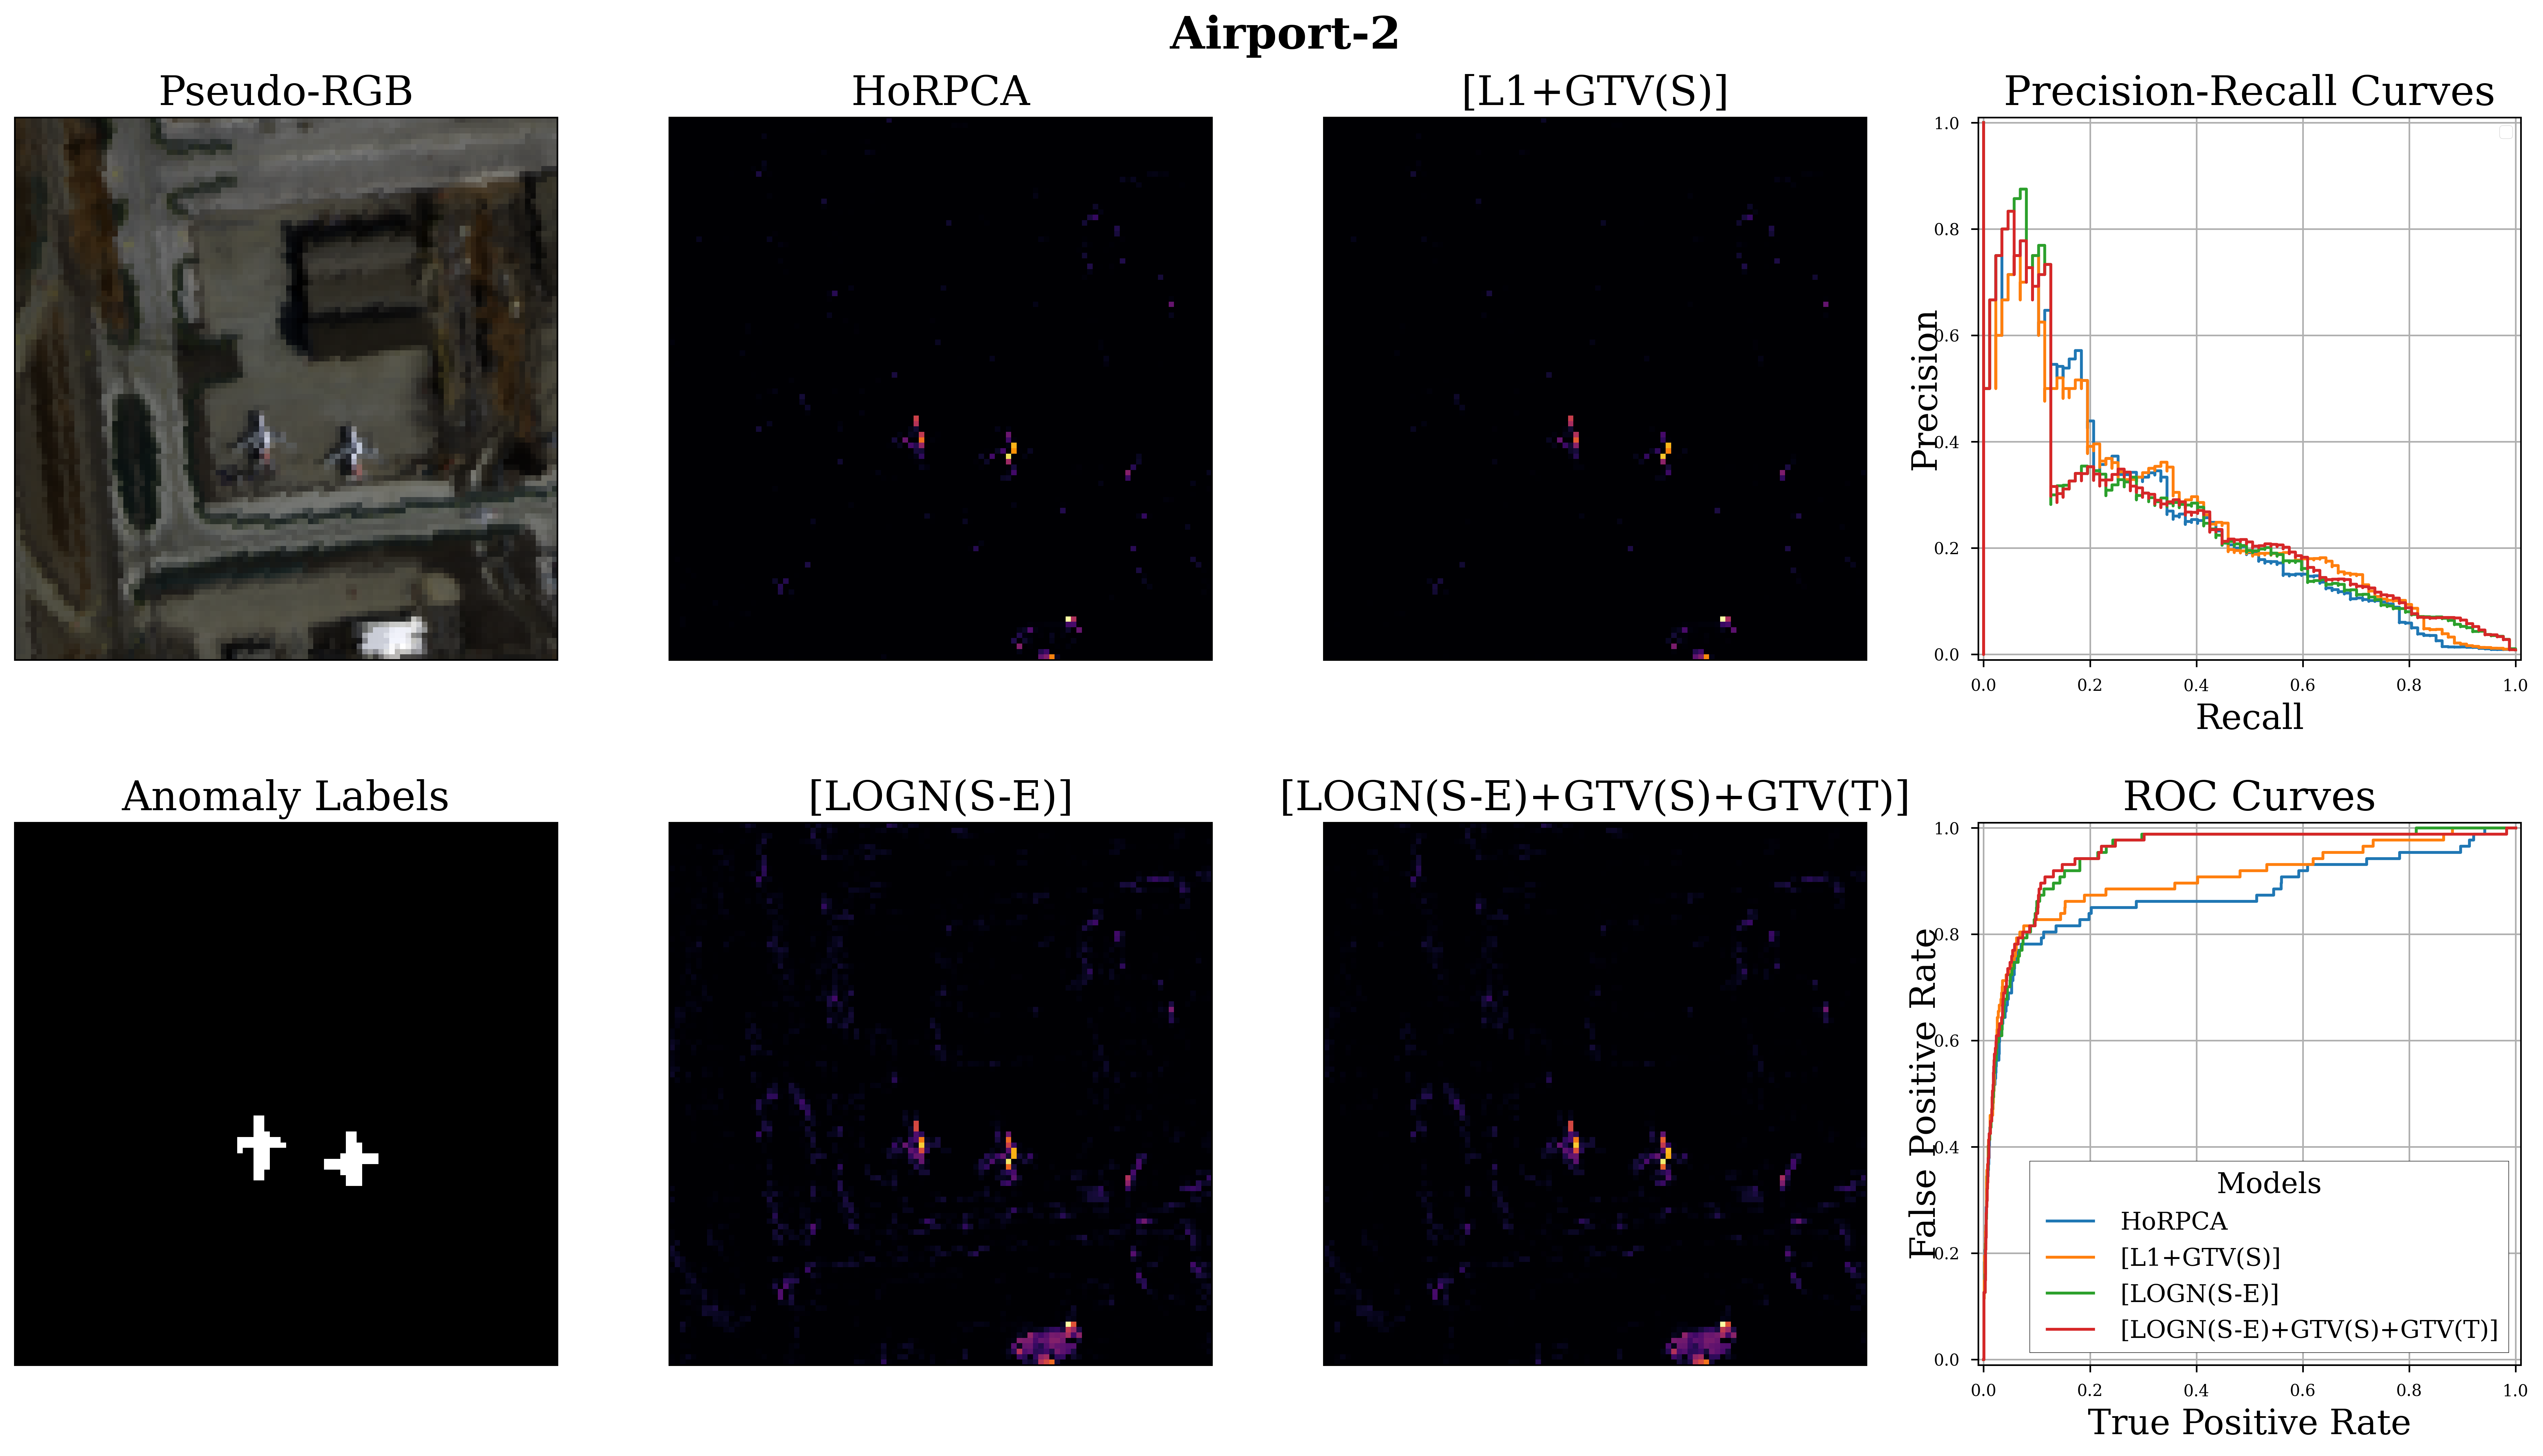

In [155]:

DECOMP_DIR = RESULTS_DIR / 'decomposed_images'

category='airport'
image_id=2
model_keys = ['HoRPCA', 'SNN_L1_GTVS_sn', 'SNN_LOGNSE', 'SNN_LOGNSE_GTVS_GTVT']
model_names = ['HoRPCA', "[L1+GTV(S)]", "[LOGN(S-E)]", "[LOGN(S-E)+GTV(S)+GTV(T)]"]
data = ABUHyperSpectral(category, image_id)
DECOMP_DIR = RESULTS_DIR / 'decomposed_images'

fig, axes = plt.subplots(2,4, figsize=(24,10),
                        #   layout='constrained'
                          )

# fig.get_layout_engine().set(w_pad=0.001, h_pad=0.001, hspace=0.001, wspace=0.001)
fig.suptitle(f"{category.capitalize()}-{image_id}", **suptitle_cfg)
axes[0,0].imshow(
    spectral.get_rgb(np.moveaxis(data.Y, 0,1)[::-1,...],(30,20,10))
)
axes[0,0].set_xticks([]);
axes[0,0].set_yticks([]);
axes[0,0].set_title("Pseudo-RGB", **title_settings)

axes[1,0].imshow(
    data.labels.T[::-1,...], cmap='gray'
)
axes[1,0].set_xticks([]);
axes[1,0].set_yticks([]);
axes[1,0].set_title(f"Anomaly Labels", **title_settings)

axs = axes[:, 1:3].flatten()
for i, m_key in enumerate(model_keys):
    m_name = model_names[i]
    file_path = DECOMP_DIR / f"{category}_{image_id}_{m_key}.npz"
    file = np.load(file_path)
    X = file['X']
    S = file['S']
    Vsum = file['Vsum']
    scale = file['scale']

    score = ((S*scale)**2).sum(axis=2)**0.5
    axs[i].imshow(score.T[::-1,...], cmap='inferno')
    axs[i].set_xticks([]);
    axs[i].set_yticks([]);
    axs[i].set_title(f"{m_name}", **title_settings)

    pr, rec, th = precision_recall_curve(data.labels.ravel(), score.ravel())
    pr_disp = PrecisionRecallDisplay(precision=pr, recall=rec, 
                                     estimator_name=m_key,
                                     )
    pr_disp.plot(ax=axes[0, 3])

    fpr, tpr, thresholds = roc_curve(data.labels.ravel(), score.ravel())
    roc_disp = RocCurveDisplay(fpr=fpr, tpr=tpr, name=m_key)
    # roc_disp.from_predictions(data.labels.ravel(), score.ravel())
    roc_disp.plot(ax=axes[1, 3])

axes[0,3].set_title('Precision-Recall Curves', **title_settings)
axes[0,3].set_xlabel('Recall', **x_label_settings)
axes[0,3].set_ylabel('Precision', **y_label_settings)
axes[0,3].legend([])
axes[0,3].grid()
axes[1,3].set_title('ROC Curves', **title_settings)
axes[1,3].set_xlabel('True Positive Rate', **x_label_settings)
axes[1,3].set_ylabel('False Positive Rate', **y_label_settings)
handles, labels = axes[1,3].get_legend_handles_labels()
# axes[1,3].legend([])
axes[1,3].legend(handles, model_names, **legend_cfg)
axes[1,3].grid()
# handles = [h.lines for h in handles]
handler_map = { h: HandlerErrorbar(numpoints=2, marker_pad=0.1, yerr_size=0.3) for h in handles}

# plt.figlegend(handles, model_names, **legend_cfg)#, )

fig.set_dpi(450)
fig.subplots_adjust(top=0.95, bottom=0.1, left=0.01, right=0.98,
                    wspace=-0.55, hspace=0.30,
                    )


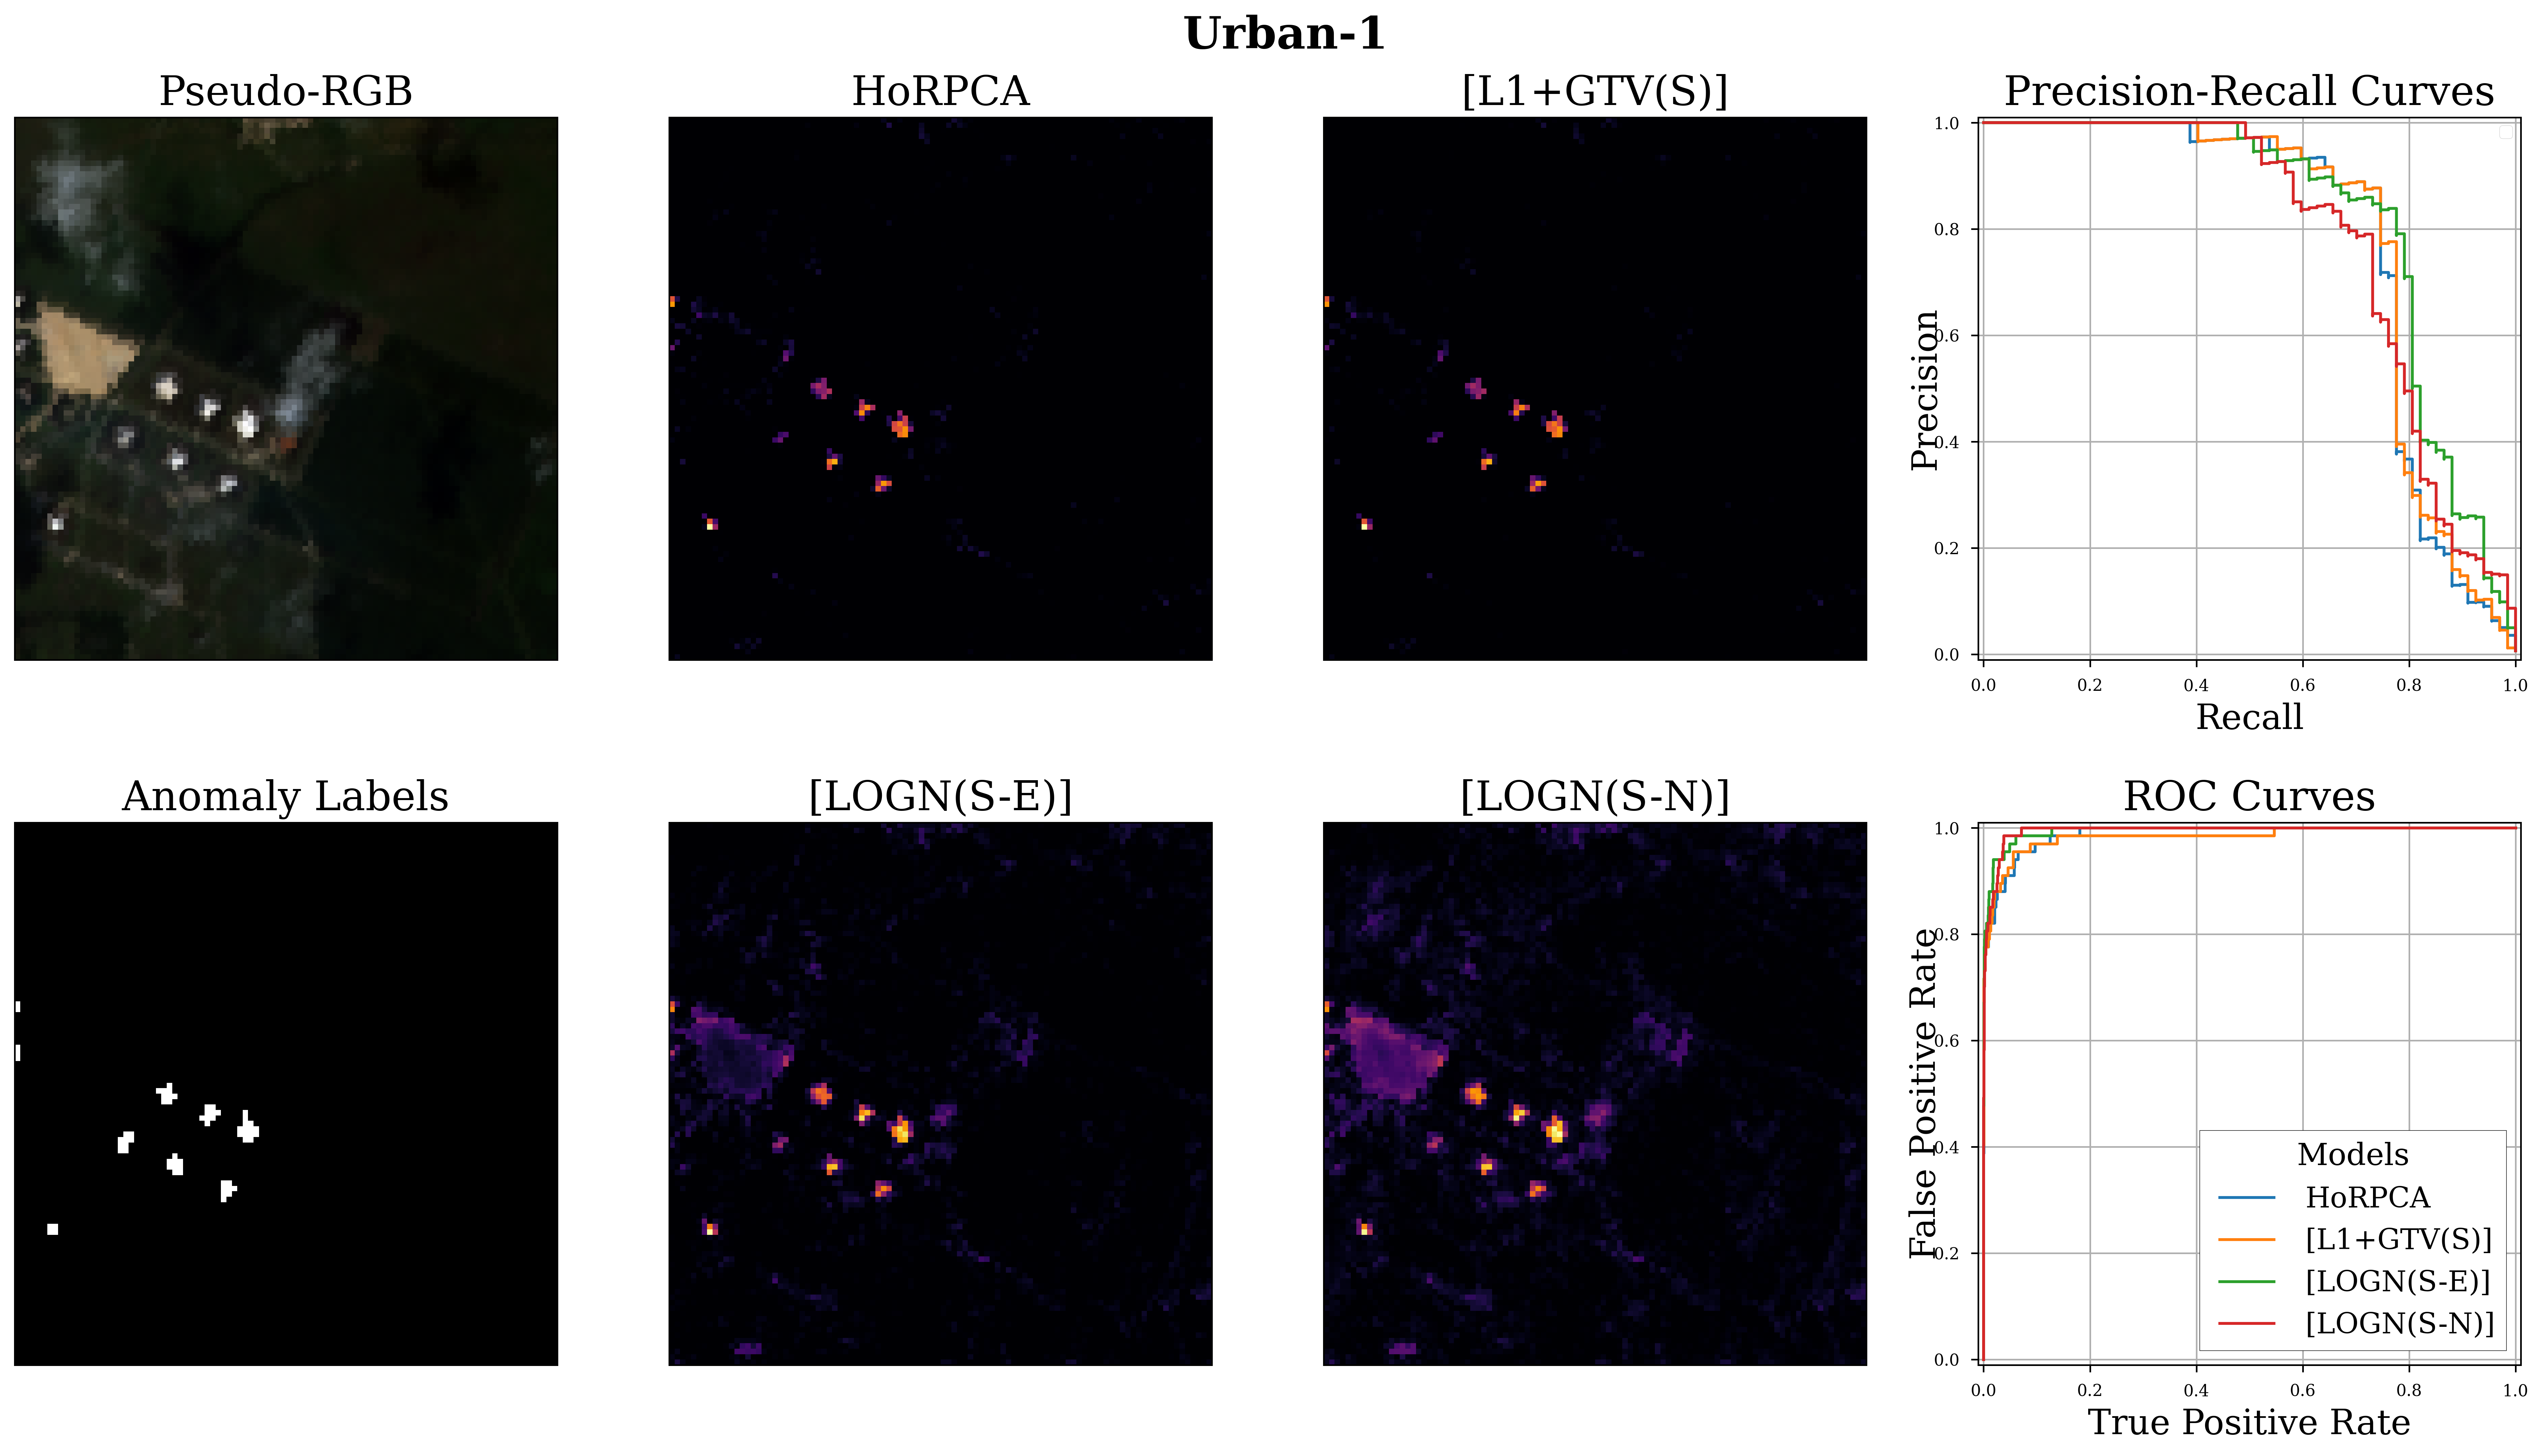

In [ ]:
DECOMP_DIR = RESULTS_DIR / 'decomposed_images'

category='urban'
image_id=1
model_keys = ['HoRPCA', 'SNN_L1_GTVS_sn', 'SNN_LOGNSE', 'SNN_LOGN']
model_names = ['HoRPCA', r"[$\ell_1$+GTV(S)]", "[LOGN(S-E)]", "[LOGN(S-N)]"]
data = ABUHyperSpectral(category, image_id)

fig, axes = plt.subplots(2,4, figsize=(24,10),
                        #   layout='constrained'
                          )

# fig.get_layout_engine().set(w_pad=0.001, h_pad=0.001, hspace=0.001, wspace=0.001)
fig.suptitle(f"{category.capitalize()}-{image_id}", **suptitle_cfg)
axes[0,0].imshow(
    spectral.get_rgb(np.moveaxis(data.Y, 0,1)[::-1,...],(30,20,10))
)
axes[0,0].set_xticks([]);
axes[0,0].set_yticks([]);
axes[0,0].set_title("Pseudo-RGB", **title_settings)

axes[1,0].imshow(
    data.labels.T[::-1,...], cmap='gray'
)
axes[1,0].set_xticks([]);
axes[1,0].set_yticks([]);
axes[1,0].set_title(f"Anomaly Labels", **title_settings)

axs = axes[:, 1:3].flatten()
for i, m_key in enumerate(model_keys):
    m_name = model_names[i]
    file_path = DECOMP_DIR / f"{category}_{image_id}_{m_key}.npz"
    file = np.load(file_path)
    X = file['X']
    S = file['S']
    Vsum = file['Vsum']
    scale = file['scale']

    score = ((S*scale)**2).sum(axis=2)**0.5
    axs[i].imshow(score.T[::-1,...], cmap='inferno')
    axs[i].set_xticks([]);
    axs[i].set_yticks([]);
    axs[i].set_title(f"{m_name}", **title_settings)

    pr, rec, th = precision_recall_curve(data.labels.ravel(), score.ravel())
    pr_disp = PrecisionRecallDisplay(precision=pr, recall=rec, 
                                     estimator_name=m_key,
                                     )
    pr_disp.plot(ax=axes[0, 3])

    fpr, tpr, thresholds = roc_curve(data.labels.ravel(), score.ravel())
    roc_disp = RocCurveDisplay(fpr=fpr, tpr=tpr, name=m_key)
    # roc_disp.from_predictions(data.labels.ravel(), score.ravel())
    roc_disp.plot(ax=axes[1, 3])

axes[0,3].set_title('Precision-Recall Curves', **title_settings)
axes[0,3].set_xlabel('Recall', **x_label_settings)
axes[0,3].set_ylabel('Precision', **y_label_settings)
axes[0,3].legend([])
axes[0,3].grid()
axes[1,3].set_title('ROC Curves', **title_settings)
axes[1,3].set_xlabel('True Positive Rate', **x_label_settings)
axes[1,3].set_ylabel('False Positive Rate', **y_label_settings)
handles, labels = axes[1,3].get_legend_handles_labels()
# axes[1,3].legend([])
axes[1,3].legend(handles, model_names, **legend_cfg)
axes[1,3].grid()
# handles = [h.lines for h in handles]
handler_map = { h: HandlerErrorbar(numpoints=2, marker_pad=0.1, yerr_size=0.3) for h in handles}

# plt.figlegend(handles, model_names, **legend_cfg)#, )

fig.set_dpi(450)
fig.subplots_adjust(top=0.95, bottom=0.1, left=0.01, right=0.98,
                    wspace=-0.55, hspace=0.30,
                    )
# fig.set_constrained_layout(constrained=True)
# fig.tight_layout()
# plt.subplot_tool(targetfig=fig)
# widg = SubplotTool(fig, fig0)
# interact(widg.)

In [28]:
%matplotlib qt
from mayavi import mlab
DECOMP_DIR = RESULTS_DIR / 'decomposed_images'

category='airport'
image_id=2
model_keys = ['HoRPCA', 'SNN_L1_GTVS_sn', 'SNN_LOGNSE', 'SNN_LOGNSE_GTVS_GTVT']
model_names = ['HoRPCA', "[L1+GTV(S)]", "[LOGN(S-E)]", "[LOGN(S-E)+GTV(S)+GTV(T)]"]
# category='urban'
# image_id=1
# model_keys = ['HoRPCA', 'SNN_L1_GTVS_sn', 'SNN_LOGNSE', 'SNN_LOGN']
# model_names = ['HoRPCA', "[L1+GTV(S)]", "[LOGN(S-E)]", "[LOGN(S-N)]"]
data = ABUHyperSpectral(category, image_id)

for i, m_key in enumerate(model_keys):
    m_name = model_names[i]
    file_path = DECOMP_DIR / f"{category}_{image_id}_{m_key}.npz"
    file = np.load(file_path)
    X = file['X']
    S = file['S']
    Vsum = file['Vsum']
    scale = file['scale']

    score = ((S*scale)**2).sum(axis=2)**0.5
    fig = mlab.figure(bgcolor=(0.8,0.8,0.8), fgcolor=(0.0, 0.0, 0.0), size=(700,1000))
    camera = fig.scene.camera
    camera.parallel_scale = 0
    mlab.volume_slice(
        #mlab.imshow(
        # data.labels,
        score,
        # extent=[(1+i%2)/2, (1+i%2)/2, (i//2)%2, (1+i//2)%2, 0,0.001],
        colormap='inferno',#'gray', #'black-white',
        plane_opacity=1.0,
        opacity=1.0,
        transparent=False,
        slice_index = 205,
        vmin=0,
        vmax=np.max(score), #1,
        plane_orientation='z_axes',
        figure=fig,
    )
    src = mlab.pipeline.volume(
        mlab.pipeline.scalar_field(
            np.abs(Vsum*scale),
            opacity=0.85,
            transparent=True,
            colormap='prism',
        ),
        figure=fig,
        )
    
    mlab.contour3d(
        # np.abs(Vsum),
        np.abs(Vsum*scale),
        colormap='prism',
        line_width=5.0,
       figure=fig,
       contours=50,
       opacity=0.01,
       transparent=True,
      )
    
    
    mlab.scalarbar(src,# title=r'|S| Magnitude',
                   orientation='horizontal', )
    mlab.axes(figure=fig, z_axis_visibility=False, x_axis_visibility=False, y_axis_visibility=False)
    # mlab.zlabel("Spectrum", src)
    # mlab.ylabel("Labels", src)
    mlab.outline(
        src,
        color=(0, 0, 0),
        figure=fig,
        )
    mlab.title(f"{category.capitalize()}-{image_id}: {m_name}", size=0.5)
    mlab.view(305, 50, 545,figure=fig)

In [ ]:
# fig, ax = plt.subplots(1,2, figsize=(10,10))
fig = plt.figure(num=0, figsize=(6, 6))
# sfigs = fig.subfigures(1,2)
view = spectral.imshow(
    np.moveaxis(data.Y, 0,1)[::-1,...],
    (30,20,10),
    classes=data.labels,
    title='Urban 1',
    fignum=0,
    )
view.set_display_mode('overlay')
view.class_alpha=0.0
view.axes.set_xticks([]);
view.axes.set_yticks([]);
view.axes.set_title("Urban-1 Pseudo RGB", fontsize=20)
fig.set_dpi(450)
# ax = fig.add_subplot(1,2, 1)
# ax.imshow(data.labels.T[::-1,:])
